In [1]:
# ¿Cómo podemos anticipar si una frase de una noticia financiera comunica una señal positiva, negativa o neutral?

# El archivo contiene frases financieras etiquetadas, por lo que permite vincular el texto con una tarea predictiva concreta.

from pathlib import Path
import os

import pandas as pd

DATA_PATH = Path("../data/sentences.csv.gz")
SUBMISSION_PATH = Path("../submission")
assert DATA_PATH.is_file(), f"No se encontró el archivo de datos: {DATA_PATH}"
assert DATA_PATH.stat().st_size > 0, f"El archivo de datos está vacío: {DATA_PATH}"
assert SUBMISSION_PATH.is_dir(), f"No se encontró el directorio de artefactos: {SUBMISSION_PATH}"
assert os.access(SUBMISSION_PATH, os.W_OK), f"No hay permiso de escritura en: {SUBMISSION_PATH}"

dataframe = pd.read_csv(
    DATA_PATH,
    index_col=False,
    compression="gzip",
)

In [2]:
# ¿Cuántas frases están disponibles para entrenar y evaluar el clasificador?

dataframe.shape

(2264, 2)

In [3]:
# Se inspeccionan las variables que describen cada mensaje y su sentimiento observado.

dataframe.head()

,phrase,target
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


In [4]:
# ¿Las clases de sentimiento están balanceadas?

dataframe.target.value_counts()

target
neutral     1391
positive     570
negative     303
Name: count, dtype: int64

In [5]:
# Se revisan ejemplos de frases positivas para contextualizar la etiqueta.

for i in range(5):
    print(dataframe[dataframe.target == "positive"]["phrase"].iloc[i])

For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m 
In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn 
Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007 representing 7.7 % of net sales 
Operating profit totalled EUR 21.1 mn , up from EUR 18.6 mn in 2007 , representing 9.7 % of net sales 
Finnish Talentum reports its operating profit increased to EUR 20.5 mn in 2005 from EUR 9.3 mn in 2004 , and net sales totaled EUR 103.3 mn , up from EUR 96.4 mn 


In [6]:
# Se revisan ejemplos de frases negativas para contextualizar la etiqueta.

for i in range(5):
    print(dataframe[dataframe.target == "negative"]["phrase"].iloc[i])

Jan. 6 -- Ford is struggling in the face of slowing truck and SUV sales and a surfeit of up-to-date , gotta-have cars 
Pharmaceuticals group Orion Corp reported a fall in its third-quarter earnings that were hit by larger expenditures on R&D and marketing 
However , the growth margin slowed down due to the financial crisis 
2009 3 February 2010 - Finland-based steel maker Rautaruukki Oyj ( HEL : RTRKS ) , or Ruukki , said today it slipped to a larger-than-expected pretax loss of EUR46m in the fourth quarter of 2009 from a year-earlier profit of EUR45m 
( ADPnews ) - Feb 3 , 2010 - Finland-based steel maker Rautaruukki Oyj ( HEL : RTRKS ) , or Ruukki , said today it slipped to a larger-than-expected pretax loss of EUR 46 million ( USD 64.5 m ) in the fourth quarter of 2009 from 


In [7]:
# Se revisan ejemplos de frases neutrales para contextualizar la etiqueta.

for i in range(5):
    print(dataframe[dataframe.target == "neutral"]["phrase"].iloc[i])

According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing 
At the request of Finnish media company Alma Media 's newspapers , research manager Jari Kaivo-oja at the Finland Futures Research Centre at the Turku School of Economics has drawn up a future scenario for Finland 's national economy by using a model developed by the University of Denver 
STOCK EXCHANGE ANNOUNCEMENT 20 July 2006 1 ( 1 ) BASWARE SHARE SUBSCRIPTIONS WITH WARRANTS AND INCREASE IN SHARE CAPITAL A total of 119 850 shares have been subscribed with BasWare Warrant Program 
A maximum of 666,104 new shares can further be subscribed for by exercising B options under the 2004 stock option plan 
Tiimari operates 194 stores in six countries -- including its core Finnish market -- and generated a turnover of 76.5 mln eur in 2005 


In [8]:
# Se reservan mensajes de cada sentimiento para evaluar predicciones sobre datos no vistos.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    dataframe.phrase,
    dataframe.target,
    test_size=0.3,
    random_state=0,
    stratify=dataframe.target,
)

In [9]:
# Se construye una matriz documento-término que convierte cada frase en variables numéricas.

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    lowercase=True,
    analyzer="word",
    token_pattern=r"\b[a-zA-Z]\w+\b",
    stop_words="english",
    max_df=0.99,
    min_df=2,
    binary=True,
)

X_train_vectorized = vectorizer.fit_transform(X_train)
vocabulary = vectorizer.get_feature_names_out()

print(f"Frases de entrenamiento: {X_train_vectorized.shape[0]}")
print(f"Términos del vocabulario: {X_train_vectorized.shape[1]}")
pd.DataFrame({"term": vocabulary[:20]})

Frases de entrenamiento: 1584
Términos del vocabulario: 1789


,term
0,ab
1,abb
2,able
3,abn
4,abp
5,ac
6,access
7,accessories
8,accordance
9,according


In [10]:
# Se ajusta un clasificador que asigne una probabilidad a cada sentimiento posible.

from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000, random_state=0)

clf.fit(
    X_train_vectorized,
    y_train,
)

LogisticRegression(max_iter=1000, random_state=0)

In [11]:
# Se compara el desempeño de entrenamiento y prueba para detectar una posible brecha de generalización.

from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

# Precisión de entrenamiento:

accuracy_score(
    y_true=y_train,
    y_pred=clf.predict(X_train_vectorized),
)

0.9835858585858586

In [12]:
# La precisión por sí sola puede ocultar fallas en clases menos frecuentes.

X_test_vectorized = vectorizer.transform(X_test)
predictions = clf.predict(X_test_vectorized)

test_accuracy = accuracy_score(y_true=y_test, y_pred=predictions)
test_balanced_accuracy = balanced_accuracy_score(y_true=y_test, y_pred=predictions)
test_macro_f1 = f1_score(y_true=y_test, y_pred=predictions, average="macro")

test_accuracy, test_balanced_accuracy, test_macro_f1

(0.8397058823529412, 0.7339512339512341, 0.7656536870176858)

Matriz de confusión:
[[ 51  28  12]
 [  2 405  11]
 [ 14  42 115]]


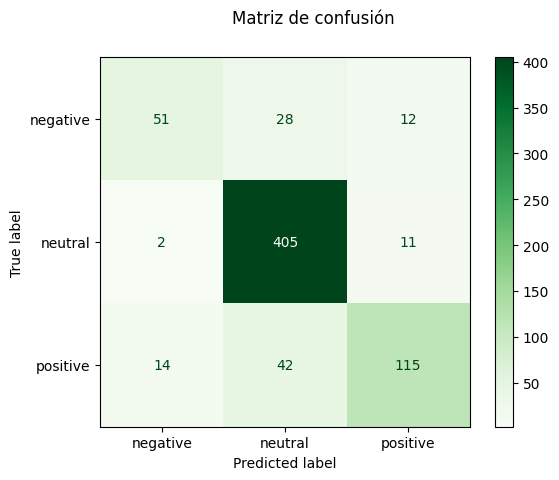

In [13]:
# La matriz muestra qué clases confunde el modelo y evita interpretar una única métrica como evidencia suficiente.

from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    cmap="Greens",
)
disp.figure_.suptitle("Matriz de confusión")
print(f"Matriz de confusión:\n{disp.confusion_matrix}")

In [14]:
# Se guardan el modelo, el vectorizador y las métricas de prueba como evidencia verificable.

import json
import pickle

with open("../submission/clf.pkl", "wb") as file:
    pickle.dump(clf, file)

with open("../submission/vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)

metrics = {
    "test_accuracy": test_accuracy,
    "test_balanced_accuracy": test_balanced_accuracy,
    "test_macro_f1": test_macro_f1,
    "test_size": len(y_test),
}

with open("../submission/metrics.json", "w", encoding="utf-8") as file:
    json.dump(metrics, file, indent=2)

In [15]:
# Se comprueba que los objetos almacenados conservan las clases y permiten interpretar una predicción concreta.

with open("../submission/clf.pkl", "rb") as file:
    new_clf = pickle.load(file)

with open("../submission/vectorizer.pkl", "rb") as file:
    new_vectorizer = pickle.load(file)

new_predictions = new_clf.predict(new_vectorizer.transform(X_test))
new_predicted_proba = new_clf.predict_proba(new_vectorizer.transform(X_test))

results = pd.DataFrame(
    {
        "phrase": X_test.reset_index(drop=True),
        "observed_target": y_test.reset_index(drop=True),
        "predicted_target": new_predictions,
        "prediction_probability": new_predicted_proba.max(axis=1),
    }
)
results["prediction_probability"] = results["prediction_probability"].round(3)
results.head(10)

,phrase,observed_target,predicted_target,prediction_probability
0,The pretax profit of the group 's life insuran...,positive,positive,0.891
1,Operating income rose to EUR 696.4 mn from EUR...,positive,positive,0.974
2,Major Order in India Comptel Corporation has r...,positive,neutral,0.526
3,Finnish food industry company L+ï¿½nnen Tehtaa...,neutral,neutral,0.843
4,RSA 's shares closed at 156.9 p at the time of...,neutral,neutral,0.954
5,"In sales volume , Coca-Cola 's market share ha...",negative,negative,0.936
6,Profit after taxes for the period was up to EU...,positive,positive,0.607
7,"The total number of voting rights is 74,612,523",neutral,neutral,0.988
8,"The study evaluated the safety , tolerability ...",neutral,neutral,0.931
9,Finnish pharmaceuticals company Orion reports ...,positive,negative,0.555
